# **Famous Transfer Learning Models**

| Model                    | Parameters | Speed     | Accuracy     | Industry     |
| ------------------------ | ---------- | --------- | ------------ | ------------ |
| VGG16                    | 138M       | Slow      | Good         | Old          |
| VGG19                    | 144M       | Slow      | Good         | Old          |
| ResNet50                 | 25M        | Medium    | Excellent    | Very common  |
| ResNet101                | 44M        | Slow      | Better       | Research     |
| InceptionV3              | 24M        | Fast      | Excellent    | Common       |
| Xception                 | 23M        | Fast      | Excellent    | Common       |
| DenseNet121              | 8M         | Medium    | Excellent    | Common       |
| MobileNetV2              | 3.5M       | Very Fast | Good         | Mobile       |
| MobileNetV3              | 5M         | Very Fast | Better       | Mobile       |
| EfficientNetB0           | 5M         | Fast      | Excellent    | Very common  |
| EfficientNetB7           | 66M        | Slow      | State of art | High-end GPU |
| ConvNeXt                 | Large      | Medium    | Excellent    | Modern       |
| Vision Transformer (ViT) | Huge       | Medium    | Excellent    | Modern       |


| Model          | Size |
| -------------- | ---- |
| VGG16          | 224  |
| ResNet50       | 224  |
| MobileNet      | 224  |
| EfficientNetB0 | 224  |
| Inception      | 299  |
| Xception       | 299  |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D,GlobalAveragePooling2D,Dropout,BatchNormalization,Flatten

In [2]:
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
import os
import kagglehub

# download the dataset
path = kagglehub.dataset_download("d4rklucif3r/cat-and-dogs")

# List the contents of the downloaded path
print(os.listdir(path))

100%|██████████| 218M/218M [00:01<00:00, 179MB/s]

Extracting files...


['dataset']


In [4]:
dataset_path = os.path.join(path, 'dataset')
print(os.listdir(dataset_path))

['test_set', 'training_set', 'single_prediction']


In [5]:
training_set_path = os.path.join(dataset_path, 'training_set')
cats_path = os.path.join(training_set_path, 'cats')
dogs_path = os.path.join(training_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/training_set/cats
Dogs image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/training_set/dogs


In [6]:
test_set_path = os.path.join(dataset_path, 'test_set')
cats_path = os.path.join(test_set_path, 'cats')
dogs_path = os.path.join(test_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/test_set/cats
Dogs image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/test_set/dogs


In [7]:
prediction_set_path = os.path.join(dataset_path, 'single_prediction')
cats_path = os.path.join(prediction_set_path, 'cats')
dogs_path = os.path.join(prediction_set_path, 'dogs')

print(f"Cats image folder path: {cats_path}")
print(f"Dogs image folder path: {dogs_path}")

Cats image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/single_prediction/cats
Dogs image folder path: /root/.cache/kagglehub/datasets/d4rklucif3r/cat-and-dogs/versions/1/dataset/single_prediction/dogs


In [8]:
train_data_set=tf.keras.utils.image_dataset_from_directory(
    training_set_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    label_mode='binary'
)
for image_batch, labels_batch in train_data_set.take(1):
    print(f"Shape of image batch: {image_batch.shape}")
    print(f"Shape of labels batch: {labels_batch.shape}")

Found 8000 files belonging to 2 classes.
Shape of image batch: (32, 224, 224, 3)
Shape of labels batch: (32, 1)


In [9]:
test_data_set=tf.keras.utils.image_dataset_from_directory(
    test_set_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    label_mode='binary'
)
for image_batch, labels_batch in test_data_set.take(1):
    print(f"Shape of image batch: {image_batch.shape}")
    print(f"Shape of labels batch: {labels_batch.shape}")

Found 2000 files belonging to 2 classes.
Shape of image batch: (32, 224, 224, 3)
Shape of labels batch: (32, 1)


In [10]:
prediction_data_set = tf.keras.utils.image_dataset_from_directory(
    prediction_set_path,
    labels=None,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 2 files.


In [11]:
train_data_set=train_data_set.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [12]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("flip",input_shape=(224,224,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
optimizer=tf.keras.optimizers.AdamW(learning_rate=0.00001)

In [17]:
model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

In [18]:
early=EarlyStopping(monitor='val_loss',patience=7,restore_best_weights=True,verbose=True)

In [19]:
history=model.fit(train_data_set,epochs=100,batch_size=32,validation_data=test_data_set,callbacks=[early])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 132ms/step - accuracy: 0.7983 - loss: 0.4361 - val_accuracy: 0.9525 - val_loss: 0.1886
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9367 - loss: 0.1898 - val_accuracy: 0.9710 - val_loss: 0.1095
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.9566 - loss: 0.1269 - val_accuracy: 0.9720 - val_loss: 0.0864
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.9611 - loss: 0.1065 - val_accuracy: 0.9750 - val_loss: 0.0748
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9678 - loss: 0.0901 - val_accuracy: 0.9755 - val_loss: 0.0685
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9726 - loss: 0.0815 - val_accuracy: 0.9765 - val_loss: 0.0644
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.9740 - loss: 0.0720 - val_accuracy: 0.9750 - val_loss: 0.0621
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.9755 -

In [20]:
loss,accuracy=model.evaluate(test_data_set)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9815 - loss: 0.0535
Loss: 0.05354411154985428
Accuracy: 0.9815000295639038


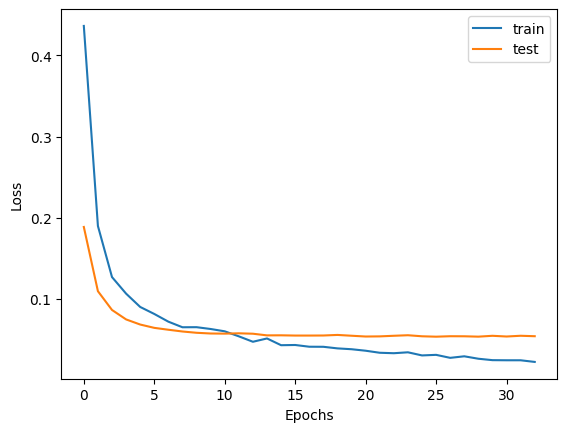

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','test'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

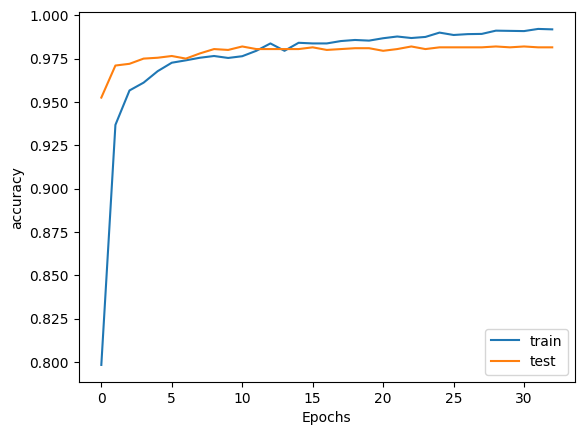

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','test'])
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.show()

In [23]:
prediction=model.predict(prediction_data_set)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


array([[9.9999869e-01],
       [5.2449366e-05]], dtype=float32)

.


# **Fine Tuning:**

In [24]:
len(base_model.layers)

175

In [25]:
base_model.trainable = True

In [26]:
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [30]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    )
]

In [32]:
history = model.fit(
    train_data_set,
    validation_data=test_data_set,
    epochs=20,
    callbacks=[callbacks]
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.9871 - loss: 0.0372 - val_accuracy: 0.9780 - val_loss: 0.0568
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 124ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.9795 - val_loss: 0.0547
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.9962 - loss: 0.0160 - val_accuracy: 0.9805 - val_loss: 0.0560
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 121ms/step - accuracy: 0.9981 - loss: 0.0100 - val_accuracy: 0.9805 - val_loss: 0.0583
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 117ms/step - accuracy: 0.9990 - loss: 0.0073 - val_accuracy: 0.9790 - val_loss: 0.0612
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.9994 - loss: 0.0052 - val_accuracy: 0.9810 - val_loss: 0.0624
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 118ms/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9805 - val_loss: 0.0646


In [33]:
loss,accuracy=model.evaluate(test_data_set)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.9795 - loss: 0.0547
Loss: 0.05467523634433746
Accuracy: 0.9794999957084656


In [35]:
prediction2=model.predict(prediction_data_set)
prediction2

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


array([[9.9999762e-01],
       [1.3762602e-04]], dtype=float32)

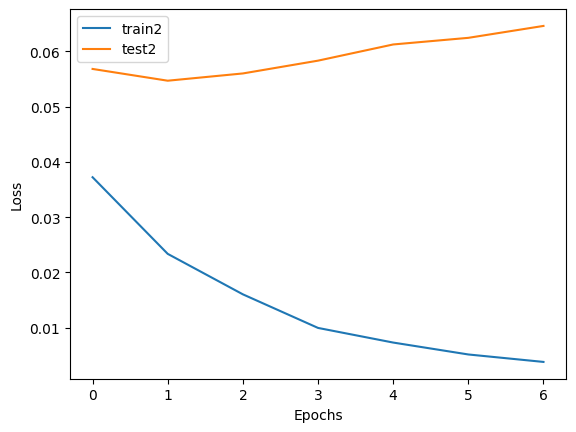

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train2','test2'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

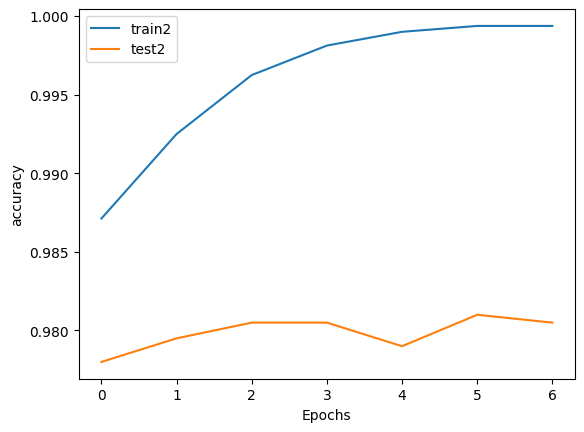

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train2','test2'])
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.show()

In [38]:
from keras.utils import plot_model

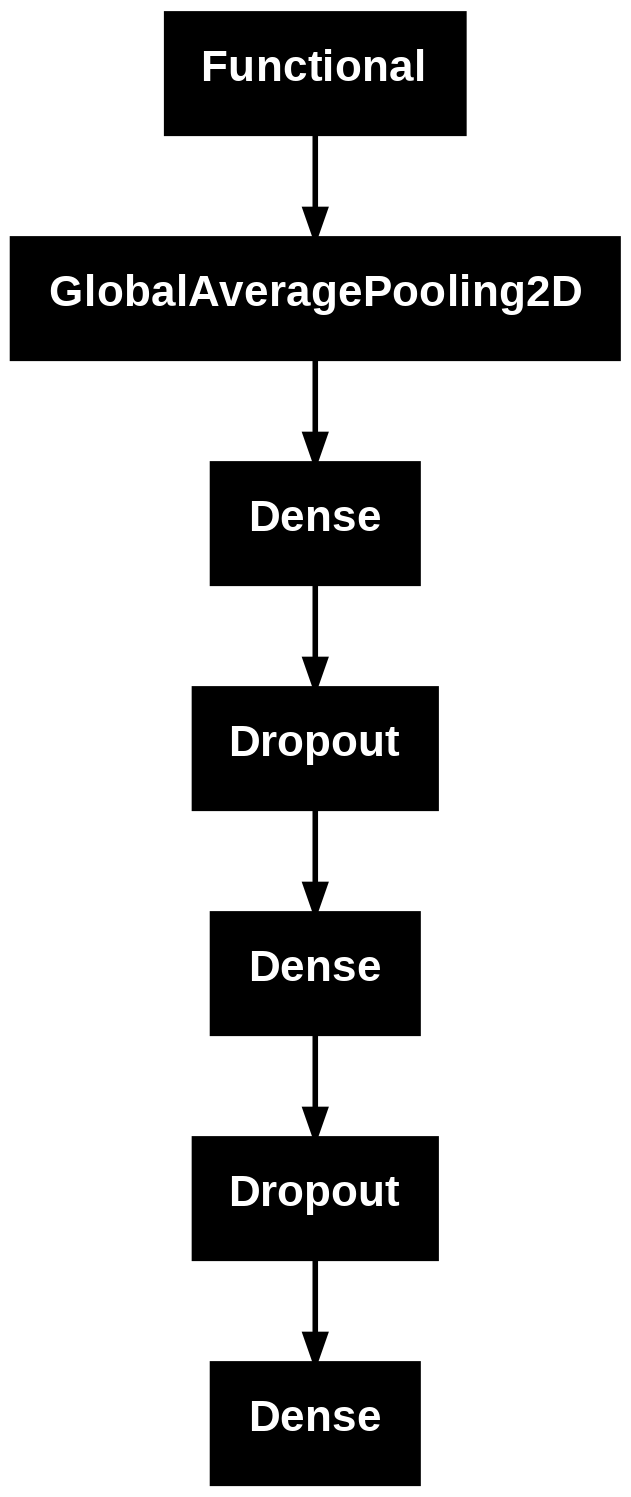

In [39]:
plot_model(model)

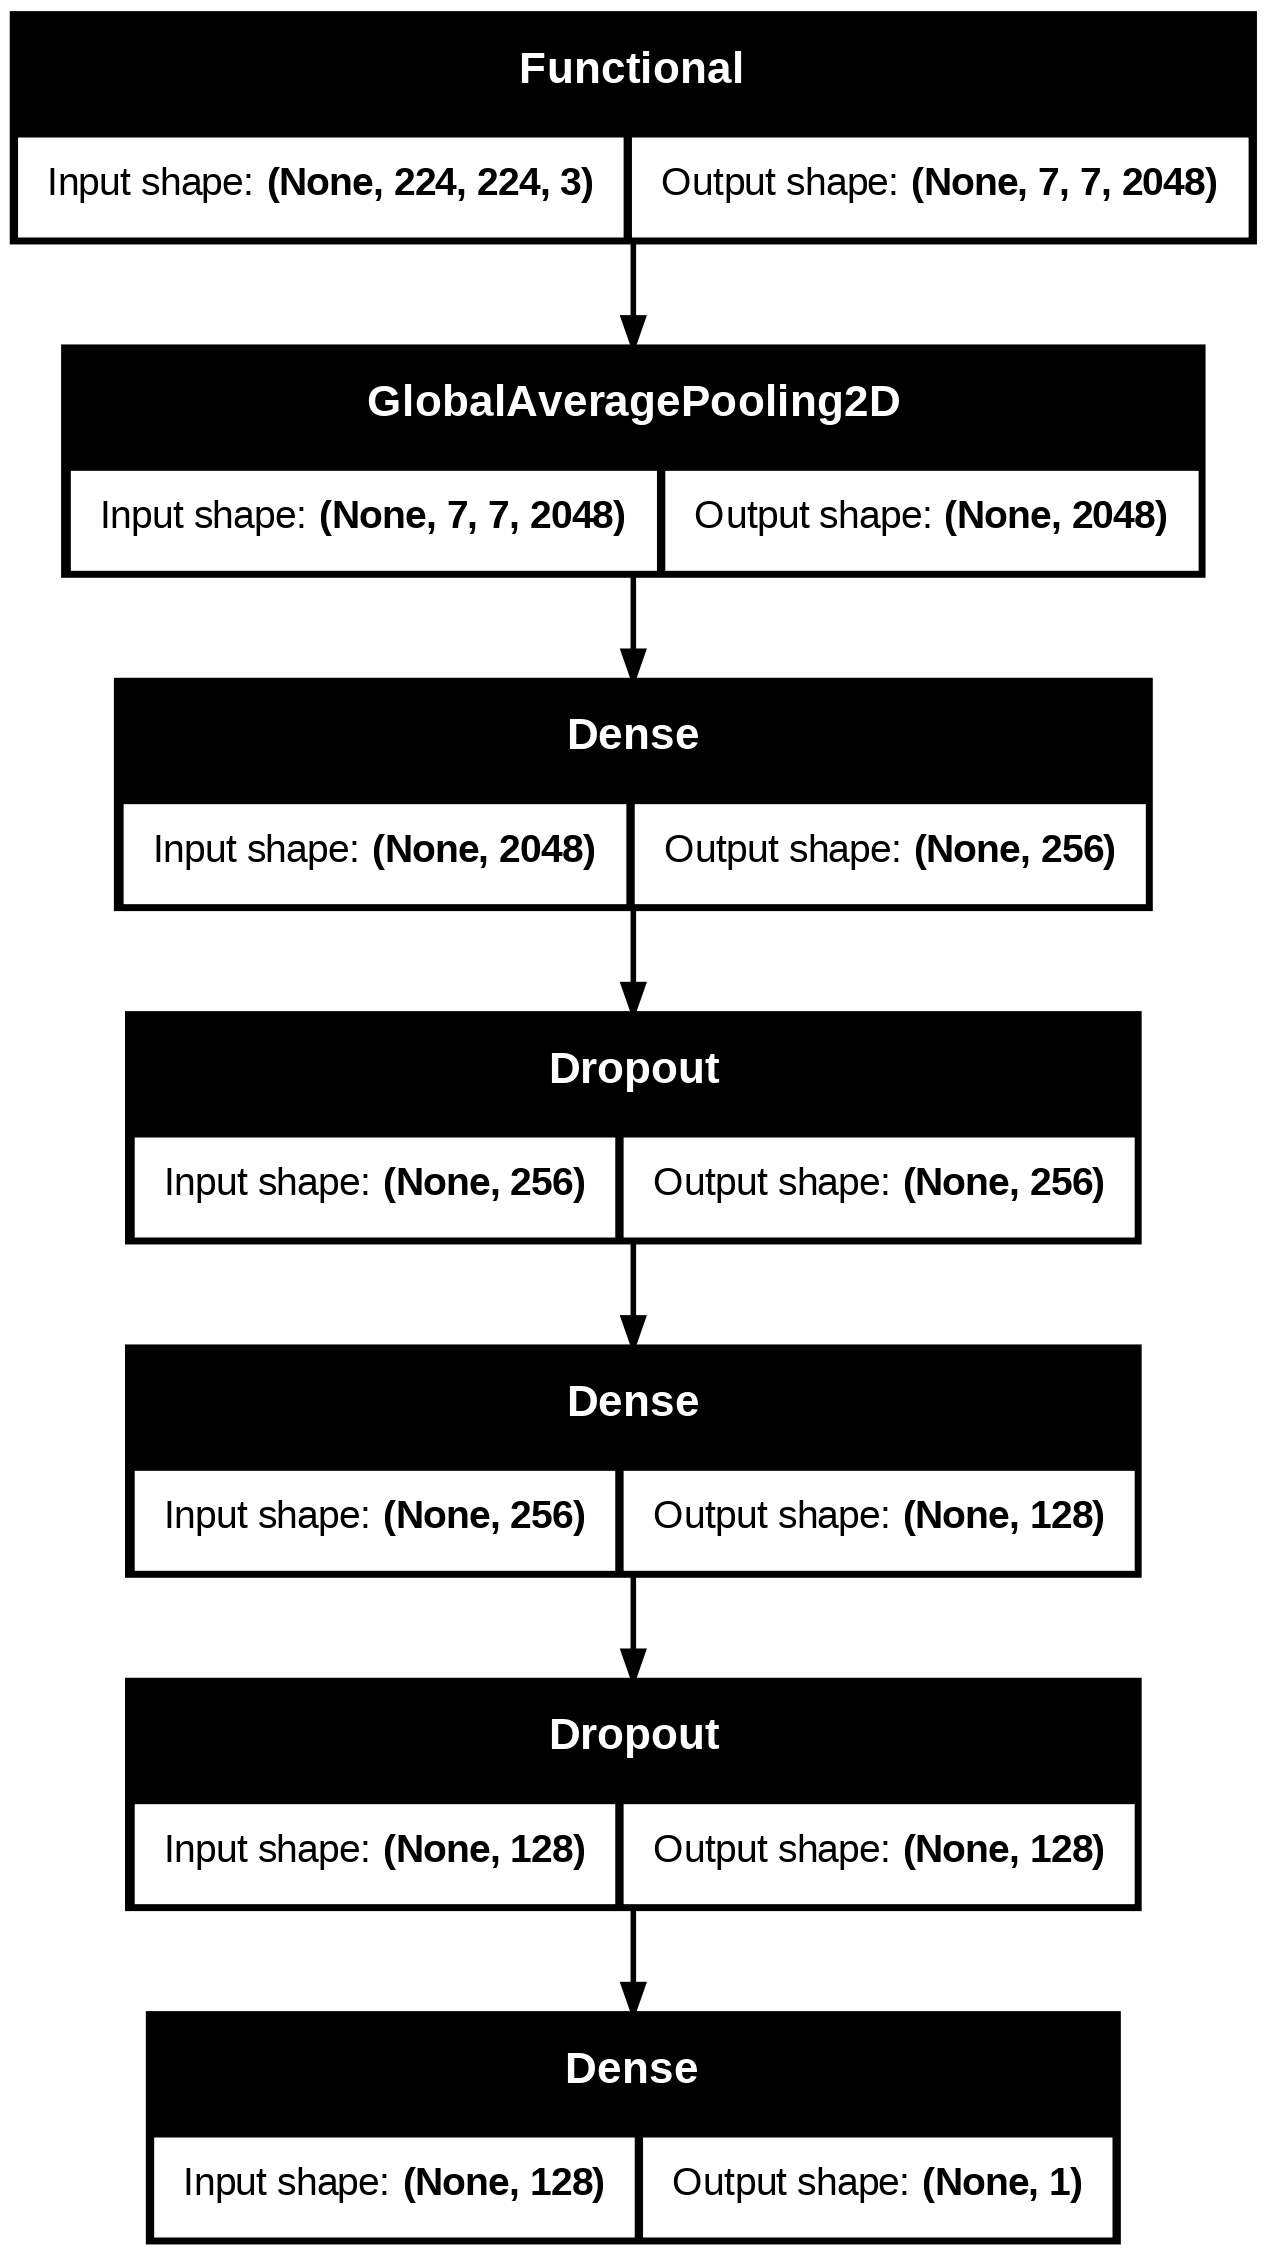

In [40]:
plot_model(model,show_shapes=True)